# Titanic: The Fate of Passengers

 *From exploratory dashboard insights to an interpretable machine learning pipeline*

<br>

**Tools used:** Power BI · Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

## Introduction

> The goal of this project is to develop an interpretable machine learning model that predicts whether a Titanic passenger survived, using insights from an exploratory Power BI dashboard and validating the final approach through a cross-validated Python pipeline.

This project combines **business-oriented visual exploration** with **predictive modeling**. The analysis begins with a Power BI dashboard to identify initial survival patterns across passenger characteristics such as **sex, class, age, embarkation point, and family structure**. These observations are then translated into a structured machine learning workflow in Python.

The notebook focuses not only on predictive performance, but also on **interpretability, methodological clarity, and portfolio-ready presentation**.

---

**Analytical workflow**

1. Exploratory data analysis in Power BI  
2. Data preparation and feature engineering  
3. Cross-validated machine learning pipeline  
4. Feature selection and interpretation  
5. Final evaluation and conclusions  

---

**Prediction target**

- **Target variable:** `Survived`
- **Task type:** Binary classification

## Dataset and Analytical Context

The analysis is based on the **Titanic passenger dataset**, where each row represents one passenger and the target variable indicates whether the passenger **survived** or **did not survive**.

The dataset contains a mix of demographic, travel-related, and family-related variables that can be used to model survival outcomes.

---

**Dataset overview**

- **Observations:** 891 passengers
- **Variables:** 12 columns
- **Target variable:** `Survived`
- **Task type:** Binary classification

---

**Available features**

The dataset includes the following variables:

`PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`

These variables provide information about passenger background, travel conditions, and family structure.

---

Before moving to exploratory analysis, the dataset structure and missing values are verified directly in Python.  
This step helps identify which variables may require preprocessing or feature engineering before modeling.


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score

from src.preprocessing import make_preprocessor
from src.modeling import make_logreg_pipeline, make_rf_pipeline
from src.utils import plot_conf_matrix

In [ ]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(f"Shape of dataset: {df.shape[0]}, {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape of dataset: 891, 12

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


The output confirms that the dataset contains **891 observations** and **12 variables**.  
It also shows that missing values are concentrated mainly in `Cabin` and `Age`, while `Embarked` contains only a very small number of missing records.

These findings will directly inform the preprocessing strategy in the later stages of the project.

## Exploratory Data Analysis in Power BI

Before building the machine learning pipeline, the dataset was explored visually in **Power BI**.  
The goal of this step was to identify clear survival patterns and use them as **initial hypotheses** for later modeling in Python.

The screenshots below focus on filters that visibly change the **Survival Rate** KPI and therefore provide a strong starting point for feature selection.

---

### 1. Baseline view — no filter

![Baseline Dashboard](../images/01_baseline_no_filter.png)

This view provides the overall reference point for the analysis.  
It shows the general survival rate across the full dataset and serves as the baseline for all filtered comparisons.

---

### 2. Filtered view — Sex = Female

![Dashboard - Female Passengers](../images/02_filter_sex_female.png)

When the dashboard is filtered to **female passengers**, the survival rate increases substantially relative to the baseline.  
This suggests that `Sex` is likely one of the most informative predictors in the dataset.

---

### 3. Filtered view — Sex = Male

![Dashboard - Male Passengers](../images/03_filter_sex_male.png)

In contrast, filtering the dataset to **male passengers** produces a much lower survival rate.  
Together with the previous screenshot, this creates a strong visual indication that survival outcomes differed sharply by sex.

---

### 4. Filtered view — Class = 1st Class

![Dashboard - 1st Class](../images/04_filter_class_1st.png)

Passengers traveling in **1st class** show a noticeably higher survival rate than the overall average.  
This indicates that `Pclass` may capture important differences related to access, status, or travel conditions.

---

### 5. Filtered view — Class = 3rd Class

![Dashboard - 3rd Class](../images/05_filter_class_3rd.png)

When filtering to **3rd class**, the survival rate decreases substantially.  
This reinforces the idea that passenger class is strongly associated with survival probability.

---

### 6. Filtered view — Sex = Female and Class = 1st Class

![Dashboard - Female 1st Class](../images/06_filter_female_1st_class.png)

This combined filter highlights one of the most favorable passenger profiles in the dataset.  
The result suggests that the interaction between `Sex` and `Pclass` may carry additional predictive value beyond each feature alone.

---

### 7. Filtered view — Sex = Male and Class = 3rd Class

![Dashboard - Male 3rd Class](../images/07_filter_male_3rd_class.png)

This filter shows one of the least favorable survival profiles.  
Compared with the previous screenshot, the contrast is strong and supports the idea that both `Sex` and `Pclass` should play a central role in the predictive modeling stage.

---

### Key takeaway from the dashboard

The filtered views suggest that the most important early candidates for modeling are:

- `Sex`
- `Pclass`

The dashboard also supports further examination of variables such as `Age`, `Embarked`, `SibSp`, and `Parch`, but the clearest visual differences in survival rate appear to be linked to **sex** and **passenger class**.

These observations remain exploratory at this stage and will be tested more formally in the Python workflow.

[def]: C:/Users/cerve/Desktop/PowerBI_Projects/Titanic/images/02_filter_sex_female.png

## Data Preparation and Feature Engineering

After the exploratory analysis in Power BI, the next step is to prepare the dataset for machine learning.

This section focuses on:
- identifying missing values,
- transforming raw variables,
- and creating features that can improve the predictive model.

The goal is to move from an explored dataset to a **clean and model-ready input**.

---

**Missing values overview**

The first step is to check which variables require preprocessing before modeling.


In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


> `Cabin` contains a very large proportion of missing values, while `Age` has a moderate amount of missing data.  
> `Embarked` contains only a very small number of missing records.

This suggests that `Cabin` should not be used in its raw form, while `Age` and `Embarked` can be handled through imputation.

---

**Feature engineering plan**

To improve the predictive input, several transformations are applied:

- `FamilySize` from `SibSp` and `Parch`
- `IsAlone` as an indicator of solo travel
- `Deck` extracted from `Cabin`

These features help preserve family structure and partial cabin information in a more model-friendly format.


In [ ]:
df = df.copy()
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Deck"] = df["Cabin"].str.extract(r"([A-Za-z])", expand=False)
df["Deck"] = df["Deck"].fillna("Unknown")
df[["SibSp", "Parch", "FamilySize", "IsAlone", "Cabin", "Deck"]].head()

,SibSp,Parch,FamilySize,IsAlone,Cabin,Deck
0,1,0,2,0,NaN,Unknown
1,1,0,2,0,C85,C
2,0,0,1,1,NaN,Unknown
3,1,0,2,0,C123,C
4,0,0,1,1,NaN,Unknown


> `FamilySize` captures the total number of family members traveling together, while `IsAlone` distinguishes solo travelers from passengers accompanied by relatives.

> `Deck` retains limited location-related information from the `Cabin` field without relying on the full raw cabin identifier.

---

**Deck distribution**

Before including `Deck` in the model, it is useful to inspect how frequently individual deck categories appear.


In [ ]:
df["Deck"].value_counts(dropna=False)

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

---

**Deck and survival**

To evaluate whether `Deck` may be useful for prediction, it is more informative to compare deck categories directly against the target variable rather than looking only at their frequency.


In [ ]:
# Create a table with absolute counts for each Deck and survival outcome
deck_counts = pd.crosstab(df["Deck"], df["Survived"])

# Create a table with relative proportions within each Deck
deck_props = pd.crosstab(df["Deck"], df["Survived"], normalize="index")

# Rename columns for better readability in the chart
deck_counts = deck_counts.rename(columns={0: "Did Not Survive", 1: "Survived"})
deck_props = deck_props.rename(columns={0: "Did Not Survive", 1: "Survived"})

# Sort decks by survival rate in descending order
deck_order = deck_props["Survived"].sort_values(ascending=False).index
deck_counts = deck_counts.loc[deck_order]
deck_props = deck_props.loc[deck_order]

# Calculate the total number of passengers in each deck
deck_totals = deck_counts.sum(axis=1)

# Initialize the interactive figure
fig = go.Figure()

# Add one stacked bar trace for each survival category
for col in ["Did Not Survive", "Survived"]:
    fig.add_trace(
        go.Bar(
            x=deck_props.index,
            y=deck_props[col],
            name=col,
            customdata=list(zip(deck_counts[col], deck_props[col], deck_totals)),
            hovertemplate=(
                "<b>Deck %{x}</b><br>"
                "Category: " + col + "<br>"
                "Absolute count: %{customdata[0]}<br>"
                "Relative share: %{customdata[1]:.1%}<br>"
                "Total passengers in deck: %{customdata[2]}<extra></extra>"
            )
        )
    )

# Adjust layout, legend position, axis labels, and proportions
fig.update_layout(
    title="Survival Distribution by Deck",
    barmode="stack",
    hovermode="x unified",
    yaxis=dict(
        title="Proportion",
        tickformat=".0%",
        range=[0, 1]
    ),
    xaxis=dict(title="Deck"),
    legend=dict(
        title="Target",
        orientation="h",
        yanchor="bottom",
        y=1.08,
        xanchor="center",
        x=0.5
    ),
    margin=dict(t=100, r=30, b=50, l=60),
    height=520
)

# Display the interactive chart
fig.show()

The interactive chart compares survival distributions across deck categories.  
Hovering over each segment shows both the **absolute number of passengers** and the **relative share within the given deck**.

---

**Model input selection**

The final step in this section is to define which variables will be passed into the machine learning pipeline.


In [ ]:
FEATURES = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Deck"]
TARGET = "Survived"

X = df[FEATURES]
y = df[TARGET]

numeric_features = ["Age", "Fare", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "IsAlone", "Deck"]

print("Selected features:", FEATURES)
print("Target:", TARGET)

Selected features: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Deck']
Target: Survived


**Train-test split**

To keep the final evaluation fair, the dataset is first divided into a training set and a test set.

The test set will be kept aside and used only after model selection is complete.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 8)
Test set shape: (179, 8)


The split preserves the class balance through stratification, which is important for a binary classification task such as survival prediction.

---

**Preprocessing design**

Because the dataset contains both numerical and categorical features, preprocessing must be handled separately for each feature type.

The pipeline below applies:
- median imputation and scaling to numerical variables,
- most frequent imputation and one-hot encoding to categorical variables.


In [ ]:
preprocessor = make_preprocessor(numeric_features, categorical_features)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'FamilySize']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked', 'IsAlone',
                                  'Deck'])])


This setup ensures that all preprocessing steps are applied consistently inside the machine learning workflow, reducing the risk of data leakage.

---

**Model comparison setup**

Instead of relying on a single algorithm, several classification models are compared under the same preprocessing framework.

This allows the analysis to assess whether the survival prediction task is better captured by a linear model or by tree-based methods.


In [ ]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

Including a dummy baseline helps establish whether the tested models actually learn useful structure from the data rather than simply predicting the majority class.

---

**Cross-validation**

Model performance is evaluated with **Stratified K-Fold cross-validation** on the training set.

This provides a more robust comparison than a single split and makes the model selection process more reliable.


In [ ]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy (mean)": scores["test_accuracy"].mean(),
        "Precision (mean)": scores["test_precision"].mean(),
        "Recall (mean)": scores["test_recall"].mean(),
        "F1 (mean)": scores["test_f1"].mean(),
        "ROC-AUC (mean)": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC-AUC (mean)", ascending=False)
cv_results_df

,Model,Accuracy (mean),Precision (mean),Recall (mean),F1 (mean),ROC-AUC (mean)
3,Random Forest,0.809091,0.777387,0.703704,0.736518,0.867987
1,Logistic Regression,0.807682,0.759276,0.729226,0.743332,0.857315
2,Decision Tree,0.745888,0.659433,0.696633,0.675793,0.741616
0,Dummy,0.616576,0.000000,0.000000,0.000000,0.500000


In [ ]:
plot_df = cv_results_df.sort_values("ROC-AUC (mean)", ascending=True)

fig = px.bar(
    plot_df,
    x="ROC-AUC (mean)",
    y="Model",
    orientation="h",
    text="ROC-AUC (mean)",
    title="Cross-Validated ROC-AUC by Model",
    custom_data=[
        "Accuracy (mean)",
        "Precision (mean)",
        "Recall (mean)",
        "F1 (mean)"
    ]
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "ROC-AUC: %{x:.3f}<br>"
        "Accuracy: %{customdata[0]:.3f}<br>"
        "Precision: %{customdata[1]:.3f}<br>"
        "Recall: %{customdata[2]:.3f}<br>"
        "F1-score: %{customdata[3]:.3f}<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Mean ROC-AUC",
    yaxis_title="Model",
    height=450,
    margin=dict(t=70, r=40, b=50, l=120)
)

fig.show()

The table above compares model performance across multiple metrics, with each score averaged over the cross-validation folds.

At this stage, the comparison is based only on the training data, while the test set remains untouched for the final evaluation.

The visual comparison helps identify which model performs most consistently on the training data under cross-validation.

The strongest candidate from this section will be examined in more detail in the next stage, where feature importance and model interpretation will be explored.

---

**Best model candidate**

To continue with interpretation, the best-performing model can be selected directly from the cross-validation results.


In [ ]:
# Select the best model based on mean ROC-AUC
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best model based on cross-validated ROC-AUC:", best_model_name)

Best model based on cross-validated ROC-AUC: Random Forest


## Modeling Strategy

At this stage, the analysis branches into two complementary modeling tracks.

The first track focuses on **Random Forest** as a performance-oriented model, with the goal of achieving the strongest predictive results through hyperparameter tuning.

The second track focuses on **Logistic Regression** as an interpretable model. In this case, feature selection and model simplification play a more important role, since the final objective is not only prediction, but also clear explanation of how individual variables relate to survival.

This dual approach makes it possible to compare predictive strength and interpretability side by side.

## Logistic Regression Track: Feature Selection and Tuning

This track focuses on **Logistic Regression** as the interpretable modeling approach.

The workflow is divided into two steps:

1. **Feature set comparison** on the training data only  
2. **Hyperparameter tuning** of the selected feature set

The goal is to identify a model that preserves strong predictive quality while remaining easier to explain than more complex ensemble methods.

---

**Feature set comparison**

Several feature sets are compared using the same preprocessing pipeline and **Stratified K-Fold cross-validation**.

Because this track emphasizes interpretability, model selection is based not only on predictive performance, but also on feature set simplicity.


In [ ]:
feature_sets = {
    "Core": ["Pclass", "Sex", "Age", "Fare", "Embarked"],
    "Core + FamilySize": ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize"],
    "Core + IsAlone": ["Pclass", "Sex", "Age", "Fare", "Embarked", "IsAlone"],
    "Core + Deck": ["Pclass", "Sex", "Age", "Fare", "Embarked", "Deck"],
    "Full Engineered": ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Deck"]
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

lr_feature_results = []

for feature_set_name, feature_list in feature_sets.items():
    pipeline = make_logreg_pipeline(feature_list)

    scores = cross_validate(
        pipeline,
        X_train[feature_list],
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    lr_feature_results.append({
        "Feature Set": feature_set_name,
        "Feature Count": len(feature_list),
        "Accuracy (mean)": scores["test_accuracy"].mean(),
        "Precision (mean)": scores["test_precision"].mean(),
        "Recall (mean)": scores["test_recall"].mean(),
        "F1 (mean)": scores["test_f1"].mean(),
        "ROC-AUC (mean)": scores["test_roc_auc"].mean(),
        "ROC-AUC (std)": scores["test_roc_auc"].std()
    })

lr_feature_results_df = pd.DataFrame(lr_feature_results).sort_values(
    "ROC-AUC (mean)", ascending=False
)

lr_feature_results_df.round(3)

,Feature Set,Feature Count,Accuracy (mean),Precision (mean),Recall (mean),F1 (mean),ROC-AUC (mean),ROC-AUC (std)
3,Core + Deck,6,0.806,0.757,0.729,0.739,0.859,0.033
4,Full Engineered,8,0.805,0.757,0.722,0.738,0.857,0.028
1,Core + FamilySize,6,0.805,0.766,0.707,0.733,0.855,0.023
0,Core,5,0.798,0.756,0.704,0.724,0.855,0.029
2,Core + IsAlone,6,0.794,0.749,0.700,0.719,0.852,0.027


**Selecting the preferred feature set**

The best feature set is selected using a simple interpretability rule:

- first, identify the highest ROC-AUC score,
- then keep all feature sets within a small tolerance,
- and finally choose the simplest option among those candidates.


In [ ]:
roc_auc_tolerance = 0.005

best_lr_roc_auc = lr_feature_results_df["ROC-AUC (mean)"].max()

lr_candidate_sets = lr_feature_results_df[
    lr_feature_results_df["ROC-AUC (mean)"] >= best_lr_roc_auc - roc_auc_tolerance
]

best_lr_row = lr_candidate_sets.sort_values(
    ["Feature Count", "ROC-AUC (mean)"],
    ascending=[True, False]
).iloc[0]

best_lr_feature_set_name = best_lr_row["Feature Set"]
best_lr_features = feature_sets[best_lr_feature_set_name]

print("Selected Logistic Regression feature set:", best_lr_feature_set_name)
print("Selected features:", best_lr_features)

Selected Logistic Regression feature set: Core
Selected features: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']


This feature set will now be used for hyperparameter tuning.

The selected configuration is intended to preserve a strong balance between **predictive quality** and **model simplicity**.

---

**Hyperparameter tuning**

Once the feature set is fixed, the next step is to optimize the Logistic Regression model itself.

The tuning process is still performed only on the training data, using cross-validation and ROC-AUC as the selection criterion.


In [ ]:
base_lr_pipeline = make_logreg_pipeline(best_lr_features)

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

lr_grid_search = GridSearchCV(
    estimator=base_lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    refit=True
)

lr_grid_search.fit(X_train[best_lr_features], y_train)

best_lr_pipeline = lr_grid_search.best_estimator_

print("Best Logistic Regression parameters:", lr_grid_search.best_params_)
print("Best cross-validated ROC-AUC:", round(lr_grid_search.best_score_, 3))

Best Logistic Regression parameters: {'model__C': 100, 'model__class_weight': None, 'model__penalty': 'l2'}
Best cross-validated ROC-AUC: 0.855


The grid search identifies the strongest Logistic Regression configuration for the selected feature set.

The resulting tuned pipeline will later be compared directly with the tuned Random Forest model on the held-out test set.

The Logistic Regression track is now complete:

- an interpretable feature set has been selected,
- the model has been tuned on the training data,
- and the final tuned pipeline is ready for comparison with the performance-oriented Random Forest track.

---

**Preliminary hold-out check**

Before moving to the Random Forest track, the tuned Logistic Regression pipeline can be evaluated once on the held-out test set.

This step provides an initial view of generalization performance, but the final model comparison will still be presented later in a shared evaluation section.


In [ ]:
y_test_pred_lr = best_lr_pipeline.predict(X_test[best_lr_features])
lr_test_accuracy = accuracy_score(y_test, y_test_pred_lr)

print("Logistic Regression test accuracy:", round(lr_test_accuracy, 3))

Logistic Regression test accuracy: 0.771


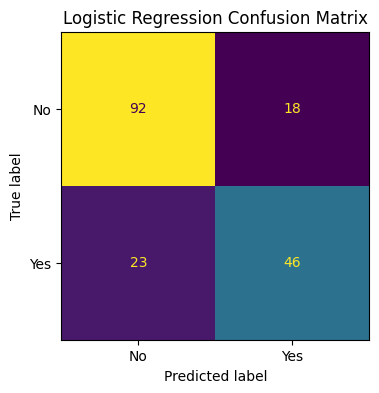

In [ ]:
plot_conf_matrix(
    y_test,
    y_test_pred_lr,
    labels=["No", "Yes"],
    title="Logistic Regression Confusion Matrix"
)

The confusion matrix shows how the tuned Logistic Regression model distributes correct and incorrect predictions across both classes.

A more complete comparison, including the tuned Random Forest model, will be presented later in the shared test-set evaluation section.

## Random Forest Track: Performance Tuning

This track treats **Random Forest** as the performance-oriented model.

Unlike the Logistic Regression track, the main objective here is not simplification, but the strongest possible predictive performance.  
For that reason, the model is trained on the **full engineered feature set** and optimized directly through hyperparameter tuning on the training data only.

---

**Feature set and preprocessing**

Because Random Forest can naturally capture non-linear patterns and feature interactions, this track uses the full feature set created during data preparation.

The same preprocessing structure is retained to ensure consistency across the modeling workflow.


In [ ]:
rf_features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Deck"]

rf_numeric_features = ["Age", "Fare", "FamilySize"]
rf_categorical_features = ["Pclass", "Sex", "Embarked", "IsAlone", "Deck"]

rf_preprocessor = make_preprocessor(rf_numeric_features, rf_categorical_features)
rf_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'FamilySize']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked', 'IsAlone',
                                  'Deck'])])

The full engineered feature set is retained in this branch because Random Forest is less sensitive to feature complexity and can benefit from richer input structure.

---

**Hyperparameter tuning**

The model is tuned with **RandomizedSearchCV** using **accuracy** as the primary selection metric.

This reflects the goal of this branch: to maximize predictive performance on the training data before moving to the final comparison stage.


In [ ]:
base_rf_pipeline = make_rf_pipeline(rf_features)

rf_param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=base_rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    random_state=42,
    refit=True
)

rf_random_search.fit(X_train[rf_features], y_train)

best_rf_pipeline = rf_random_search.best_estimator_

print("Best Random Forest parameters:", rf_random_search.best_params_)
print("Best cross-validated accuracy:", round(rf_random_search.best_score_, 3))

Best Random Forest parameters: {'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 15, 'model__bootstrap': True}
Best cross-validated accuracy: 0.833


The search above identifies the strongest Random Forest configuration under the selected accuracy-focused tuning strategy.


In [ ]:
rf_tuning_results = (
    pd.DataFrame(rf_random_search.cv_results_)[[
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features",
        "param_model__bootstrap",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]]
    .rename(columns={
        "param_model__n_estimators": "n_estimators",
        "param_model__max_depth": "max_depth",
        "param_model__min_samples_split": "min_samples_split",
        "param_model__min_samples_leaf": "min_samples_leaf",
        "param_model__max_features": "max_features",
        "param_model__bootstrap": "bootstrap",
        "mean_test_score": "Mean Accuracy",
        "std_test_score": "Std Accuracy",
        "rank_test_score": "Rank"
    })
    .sort_values("Rank")
    .head(10)
)

rf_tuning_results.round(3)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,Mean Accuracy,Std Accuracy,Rank
0,800,15,2,4,None,True,0.833,0.027,1
24,200,20,2,4,None,True,0.827,0.025,2
20,200,None,10,2,log2,True,0.818,0.028,3
2,800,5,10,1,None,False,0.813,0.041,4
23,200,15,5,4,log2,True,0.813,0.027,5
27,800,15,10,1,log2,True,0.812,0.027,6
15,200,20,5,2,sqrt,True,0.810,0.031,7
9,800,15,10,2,log2,False,0.810,0.030,8
19,400,15,5,4,sqrt,False,0.810,0.029,8
28,400,20,10,2,log2,False,0.809,0.035,10


The table highlights the best-performing Random Forest configurations found during the randomized search.

This makes it easier to assess whether the strongest result is stable or only marginally better than nearby alternatives.

---

**Preliminary hold-out check**

Before moving to the shared final comparison section, the tuned Random Forest pipeline can be evaluated once on the held-out test set.

As in the Logistic Regression branch, this serves as an early view of generalization performance rather than the final side-by-side comparison.


In [ ]:
y_test_pred_rf = best_rf_pipeline.predict(X_test[rf_features])
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)
print("Random Forest test accuracy:", round(rf_test_accuracy, 3))

Random Forest test accuracy: 0.782


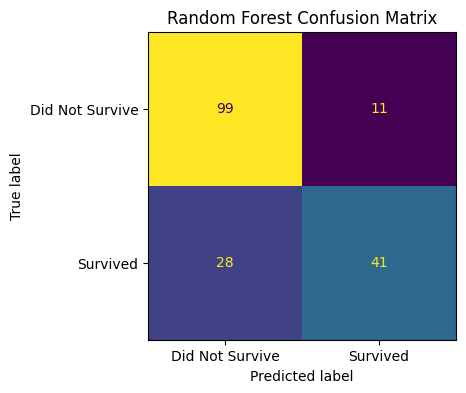

In [ ]:
plot_conf_matrix(
    y_test,
    y_test_pred_rf,
    labels=["Did Not Survive", "Survived"],
    title="Random Forest Confusion Matrix"
)

The Random Forest track is now complete:

- the full engineered feature set has been retained,
- the model has been tuned for predictive performance on the training data,
- and the final tuned pipeline is ready for direct comparison with the tuned Logistic Regression model.

### Logistic Regression Performance Across Key Passenger Groups

To connect the modeling results back to the Power BI dashboard, the tuned Logistic Regression model is evaluated across the passenger groups that showed the clearest visual differences earlier in the analysis.

The subgroup comparison focuses on:

- `Sex`
- `Pclass`
- the combined profile `Sex × Pclass`

This makes it possible to assess whether the model performs consistently across the same passenger segments that were highlighted during the exploratory stage.


In [ ]:
lr_group_eval = X_test.copy()
lr_group_eval["y_true"] = y_test.values
lr_group_eval["y_pred"] = y_test_pred_lr
lr_group_eval["Correct"] = (lr_group_eval["y_true"] == lr_group_eval["y_pred"]).astype(int)

lr_group_eval["Sex_Pclass"] = (
    lr_group_eval["Sex"].astype(str) + " | Class " + lr_group_eval["Pclass"].astype(str)
)

lr_acc_sex = (
    lr_group_eval.groupby("Sex", as_index=False)
    .agg(n=("Correct", "size"), Accuracy=("Correct", "mean"))
)

lr_acc_pclass = (
    lr_group_eval.groupby("Pclass", as_index=False)
    .agg(n=("Correct", "size"), Accuracy=("Correct", "mean"))
    .sort_values("Pclass")
)

lr_acc_sex_pclass = (
    lr_group_eval.groupby(["Sex", "Pclass"], as_index=False)
    .agg(n=("Correct", "size"), Accuracy=("Correct", "mean"))
)

for df_ in [lr_acc_sex, lr_acc_pclass, lr_acc_sex_pclass]:
    df_["AccuracyPct"] = (df_["Accuracy"] * 100).round(1)

**Accuracy by sex**


In [ ]:
fig = px.bar(
    lr_acc_sex,
    x="Sex",
    y="Accuracy",
    text="AccuracyPct",
    title="Logistic Regression Accuracy by Sex",
    custom_data=["n"]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Accuracy: %{y:.1%}<br>"
        "n: %{customdata[0]}<extra></extra>"
    )
)

fig.update_layout(
    yaxis=dict(title="Accuracy", tickformat=".0%", range=[0, 1]),
    xaxis_title="Sex",
    height=450,
    margin=dict(t=70, r=40, b=50, l=60)
)

fig.show()

**Accuracy by passenger class**


In [ ]:
fig = px.bar(
    lr_acc_pclass,
    x="Pclass",
    y="Accuracy",
    text="AccuracyPct",
    title="Logistic Regression Accuracy by Passenger Class",
    custom_data=["n"]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    hovertemplate=(
        "<b>Class %{x}</b><br>"
        "Accuracy: %{y:.1%}<br>"
        "n: %{customdata[0]}<extra></extra>"
    )
)

fig.update_layout(
    yaxis=dict(title="Accuracy", tickformat=".0%", range=[0, 1]),
    xaxis_title="Passenger Class",
    height=450,
    margin=dict(t=70, r=40, b=50, l=60)
)

fig.show()

**Accuracy by sex and passenger class**


In [ ]:
# Prepare matrix for the heatmap
heatmap_acc = (
    lr_acc_sex_pclass.pivot(index="Sex", columns="Pclass", values="Accuracy")
    .reindex(index=["female", "male"], columns=[1, 2, 3])
)

heatmap_n = (
    lr_acc_sex_pclass.pivot(index="Sex", columns="Pclass", values="n")
    .reindex(index=["female", "male"], columns=[1, 2, 3])
)

# Custom hover data with subgroup sizes
customdata = np.dstack([heatmap_n.values])

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_acc.values,
        x=[f"Class {col}" for col in heatmap_acc.columns],
        y=heatmap_acc.index,
        text=(heatmap_acc.values * 100).round(1),
        texttemplate="%{text:.1f}%",
        customdata=customdata,
        hovertemplate=(
            "<b>%{y}, %{x}</b><br>"
            "Accuracy: %{z:.1%}<br>"
            "n: %{customdata[0]}<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Logistic Regression Accuracy by Sex and Passenger Class",
    xaxis_title="Passenger Class",
    yaxis_title="Sex",
    height=450,
    margin=dict(t=70, r=40, b=50, l=80)
)

fig.show()

These accuracy views mirror the same segmentation logic used in the Power BI dashboard.

They make it easier to compare whether the Logistic Regression model performs more reliably for groups such as **female passengers**, **first-class passengers**, or **male passengers in lower classes** before moving to coefficient interpretation.

### Logistic Regression Coefficient Interpretation

After examining model performance across the key dashboard groups, the next step is to interpret how the Logistic Regression model relates individual features to survival.

Because Logistic Regression is linear in **log-odds**, the fitted coefficients describe how each transformed feature is associated with higher or lower log-odds of survival.

To make this easier to interpret, the coefficients are paired with their corresponding transformed feature names and converted into **odds ratios**.


In [ ]:
lr_preprocessor_fitted = best_lr_pipeline.named_steps["preprocessor"]
lr_model_fitted = best_lr_pipeline.named_steps["model"]

lr_coef_df = pd.DataFrame({
    "Feature": lr_preprocessor_fitted.get_feature_names_out(),
    "Coefficient": lr_model_fitted.coef_[0]
})

lr_coef_df["Odds Ratio"] = np.exp(lr_coef_df["Coefficient"])
lr_coef_df["AbsCoefficient"] = lr_coef_df["Coefficient"].abs()

lr_coef_df = lr_coef_df.sort_values("AbsCoefficient", ascending=False)

lr_coef_df.round(3).head(15)

,Feature,Coefficient,Odds Ratio,AbsCoefficient
5,cat__Sex_female,1.377,3.963,1.377
6,cat__Sex_male,-1.208,0.299,1.208
2,cat__Pclass_1,1.190,3.288,1.190
4,cat__Pclass_3,-1.176,0.309,1.176
0,num__Age,-0.456,0.634,0.456
8,cat__Embarked_Q,0.449,1.566,0.449
9,cat__Embarked_S,-0.388,0.679,0.388
3,cat__Pclass_2,0.155,1.167,0.155
7,cat__Embarked_C,0.108,1.114,0.108
1,num__Fare,0.025,1.025,0.025


A positive coefficient indicates higher **log-odds of survival**, while a negative coefficient indicates lower log-odds of survival.

The corresponding **odds ratio** can be interpreted as follows:

- **above 1** → higher odds of survival
- **below 1** → lower odds of survival
- **close to 1** → weaker association


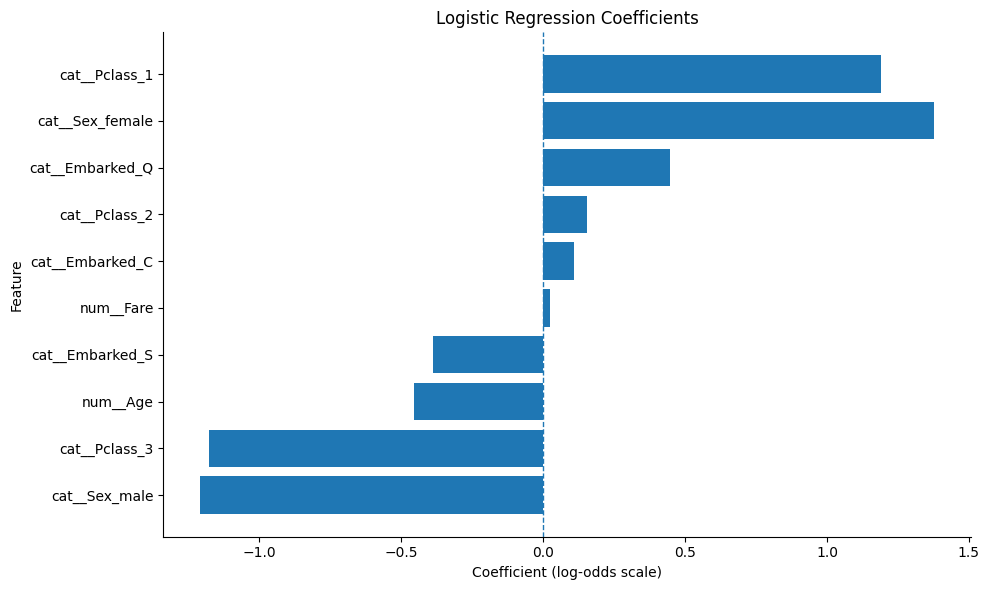

In [ ]:
top_positive = lr_coef_df.nlargest(8, "Coefficient")
top_negative = lr_coef_df.nsmallest(8, "Coefficient")

lr_coef_plot_df = pd.concat([top_negative, top_positive])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lr_coef_plot_df["Feature"], lr_coef_plot_df["Coefficient"])

ax.set_title("Logistic Regression Coefficients")
ax.set_xlabel("Coefficient (log-odds scale)")
ax.set_ylabel("Feature")
ax.axvline(0, linestyle="--", linewidth=1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Features on the **right side** of the chart are associated with higher **log-odds of survival**, while features on the **left side** are associated with lower log-odds of survival.

This makes it possible to compare the direction and relative strength of the strongest feature effects within the final Logistic Regression model.

---

**Interpretation notes**

Two points are important when reading these results:

- numerical variables were scaled before modeling,
- categorical variables were one-hot encoded into separate feature levels.

This means the coefficients are most useful for interpreting **direction** and **relative strength**, rather than raw unit changes in the original dataset.

---

**Comparison with PowerBI findings**

The coefficient patterns can now be compared directly with the earlier Power BI findings.

If features related to **sex** and **passenger class** appear among the strongest coefficients, this supports the earlier dashboard evidence and strengthens the consistency of the overall analysis.

The final Logistic Regression model confirms that variables related to **sex** and **passenger class** play a central role in survival prediction.

This is consistent with the Power BI dashboard, where the clearest survival differences were observed between **female and male passengers** and across **passenger classes**.  
The model therefore supports the earlier visual evidence not only descriptively, but also in a formal predictive setting.

## Conclusion

> This project combined **exploratory analysis in Power BI** with **predictive modeling in Python** and showed that survival on the Titanic was not random, but was strongly associated mainly with **sex** and **passenger class**.

### Key findings
- **Women** survived much more often than men.
- **1st class passengers** had a higher chance of survival than those in 2nd class, and especially 3rd class.
- Variables such as **age**, **port of embarkation**, and **family size** played a secondary role, but their impact was not as strong as sex and class.

### Modeling results
| Model | Test accuracy | Note |
|---|---:|---|
| Logistic Regression | **0.771** | better interpretability |
| Random Forest | **0.782** | slightly higher predictive performance |

### Interpretation of the results
From an analytical perspective, **Logistic Regression** proved to be the more practical model, because despite its slightly lower performance, it offered much better interpretability.  
The model coefficients confirmed that:
- being **female** increased the chance of survival,
- being in **1st class** was associated with a higher probability of survival,
- while being **male** and traveling in **3rd class** reduced the chance of survival.

